In [4]:
import sys
sys.path.append(r"C:\Users\saksh\OneDrive - University of Keele\Desktop\Ecommerce_project")

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, average_precision_score,
                             confusion_matrix, ConfusionMatrixDisplay)
import matplotlib.pyplot as plt

from src.data.loader import load_data
from src.features.engineering import add_engineered_features
from src.config.settings import load_config

config = load_config()


In [5]:
df = load_data()
df = add_engineered_features(df)
df = pd.get_dummies(df, columns=config["categorical_columns"])

X = df.drop(config["target_column"], axis=1)
y = df[config["target_column"]]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=config["test_size"], random_state=config["random_seed"]
)

2026-08-23 07:06:36,552 | INFO | src.data.loader | Data loaded successfully from C:/Users/saksh/OneDrive - University of Keele/Desktop/Ecommerce_project/dataset/ecommerce_sessions.csv.
2026-08-23 07:06:36,555 | INFO | src.data.loader | All expected columns are present in the dataset.
2026-08-23 07:06:36,583 | INFO | src.features.engineering | Engineered features added to the DataFrame.


In [6]:
models = {
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced", n_estimators=100),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, learning_rate=0.05, eval_metric="logloss", use_label_encoder=False),
    "CatBoost": CatBoostClassifier(n_estimators=100, max_depth=4, learning_rate=0.05, verbose=0),
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob),
    })

results_df = pd.DataFrame(results).sort_values("PR-AUC", ascending=False)
results_df


c:\Users\saksh\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [07:06:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
2,XGBoost,0.934583,0.809659,0.760000,0.784044,0.969029,0.864373
3,CatBoost,0.936667,0.819484,0.762667,0.790055,0.969468,0.861221
1,RandomForest,0.923750,0.850365,0.621333,0.718028,0.959440,0.845699
0,DecisionTree,0.899167,0.692754,0.637333,0.663889,0.792494,0.498182


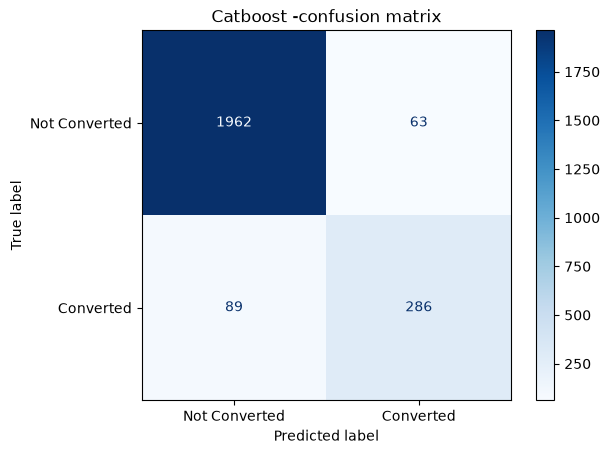

In [7]:
best_models= models["CatBoost"]
y_pred_best = best_models.predict(X_test)
cm  = confusion_matrix(y_test, y_pred_best)
dis = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Converted", "Converted"])
dis.plot(cmap="Blues")
plt.title("Catboost -confusion matrix")
plt.show()